# Student Sleep & Mental Health Analysis

## Project Overview

This project explores the relationship between students' sleep habits, stress, anxiety, social media usage, exercise, caffeine consumption, and academic performance using Pandas and NumPy.

Dataset Sourse: Kaggle

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/student_sleep_mental_health_2026.csv")

# Date Overview

Before starting the analysis, let's explore the dataset.

In [4]:
df.shape
df.info()
df.head()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               3000 non-null   int64  
 1   age                      3000 non-null   int64  
 2   gender                   3000 non-null   str    
 3   education_level          3000 non-null   str    
 4   avg_sleep_hours          3000 non-null   float64
 5   screen_time_hours        3000 non-null   float64
 6   social_media_hours       3000 non-null   float64
 7   study_hours_per_day      3000 non-null   float64
 8   exercise_hours_per_week  3000 non-null   float64
 9   caffeine_drinks_per_day  3000 non-null   int64  
 10  stress_level             3000 non-null   int64  
 11  anxiety_score            3000 non-null   int64  
 12  gpa                      3000 non-null   float64
 13  uses_sleep_app           3000 non-null   bool   
 14  feels_burned_out         3000 non-n

,student_id,age,avg_sleep_hours,screen_time_hours,social_media_hours,study_hours_per_day,exercise_hours_per_week,caffeine_drinks_per_day,stress_level,anxiety_score,gpa
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,19.445000,7.414067,6.494667,3.575033,3.235200,3.541900,1.778667,7.216667,7.152000,3.244487
std,866.169729,2.924921,0.971279,2.165014,1.563631,1.405491,2.336889,1.341496,1.572433,1.994882,0.379404
min,1.000000,14.000000,4.400000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.970000
25%,750.750000,17.000000,6.800000,5.000000,2.500000,2.300000,1.800000,1.000000,6.000000,6.000000,2.980000
50%,1500.500000,19.000000,7.400000,6.500000,3.600000,3.200000,3.400000,2.000000,7.000000,7.000000,3.245000
75%,2250.250000,21.000000,8.100000,8.000000,4.600000,4.200000,5.100000,3.000000,8.000000,9.000000,3.510000
max,3000.000000,29.000000,10.900000,13.600000,9.000000,8.700000,11.300000,8.000000,10.000000,10.000000,4.000000


## Initial Observations

After exploring the dataset, I observed the following:

- The dataset contains **3,000 student records** and **15 features**.
- There are **no missing values**, so the dataset is complete.
- The dataset includes numerical, categorical, and boolean variables.
- The numerical features include sleep duration, screen time, social media usage, study time, exercise, caffeine intake, stress level, anxiety score, and GPA.
- The dataset appears to be clean and ready for further analysis.

Question 1: What Percentage of Students Use Sleep Tracking Apps by Gender, and Which Gender Reports Higher Burnout?

In [5]:
label_count = df["uses_sleep_app"].value_counts()
true_counts_percent = (label_count[True] / len(df["uses_sleep_app"])) * 100

First, we calculate the percentage of students who use sleep tracking applications for each gender.

[Text(0, 0, '33.7838'), Text(0, 0, '34.539')]

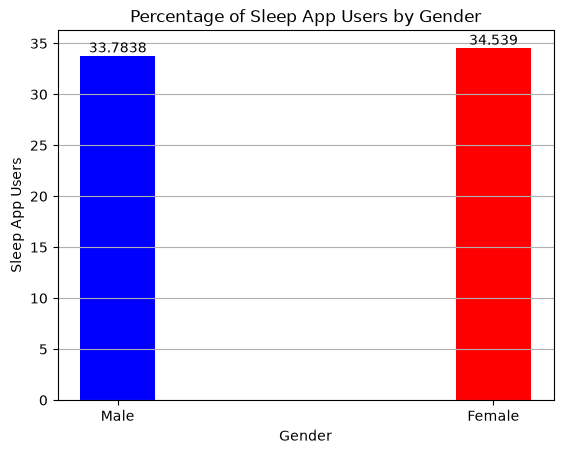

In [39]:
male_uses_sleep_app = df.query("gender == 'Male' and uses_sleep_app == True")
female_uses_sleep_app = df.query("gender == 'Female' and uses_sleep_app == True")

male_percent = (len(male_uses_sleep_app) / len(df.query("gender == 'Male'"))) * 100
female_percent = (len(female_uses_sleep_app) / len(df.query("gender == 'Female'"))) * 100

bars = plt.bar(
    ["Male", "Female"],
    [male_percent, female_percent],
    width=0.2,
    color=["blue", "red"]
    )

plt.title("Percentage of Sleep App Users by Gender")
plt.xlabel("Gender")
plt.ylabel("Sleep App Users")

plt.grid(axis="y")

plt.bar_label(bars)

Approximately 34% of female students and 33% of male students use sleep tracking applications. Next, we compare the burnout rates between students who use sleep tracking apps and those who do not.

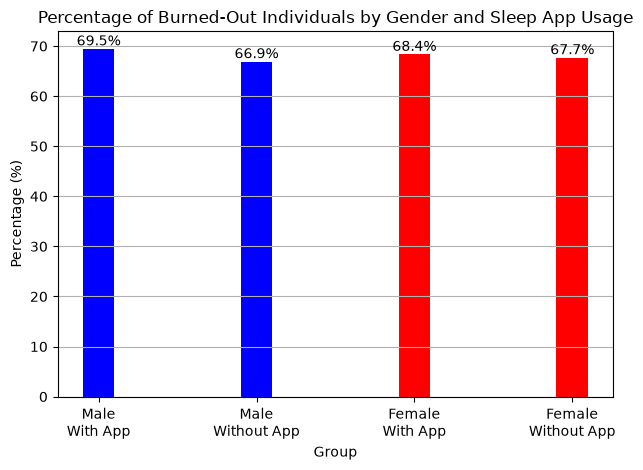

In [ ]:
burned_out_male_with_app = male_uses_sleep_app.loc[male_uses_sleep_app["feels_burned_out"] == True]
burned_out_male_without_app = df.query("gender == 'Male' and feels_burned_out == True and uses_sleep_app == False")

burned_out_male_with_app_percent = ((len(burned_out_male_with_app)) / len(male_uses_sleep_app)) * 100
burned_out_male_without_app_percent = (len(burned_out_male_without_app) / len((df.query("gender == 'Male' and uses_sleep_app == False")))) * 100

burned_out_female_with_app  = female_uses_sleep_app.loc[female_uses_sleep_app["feels_burned_out"] == True]
burned_out_female_without_app = df.query("gender == 'Female' and feels_burned_out == True and uses_sleep_app == False")

burned_out_female_with_app_percent = ((len(burned_out_female_with_app)) / len(female_uses_sleep_app)) * 100
burned_out_female_without_app_percent  = (len(burned_out_female_without_app) / len((df.query("gender == 'Female' and uses_sleep_app == False")))) * 100

bars = plt.bar(
    [ "Male\nWith App",
    "Male\nWithout App",
    "Female\nWith App",
    "Female\nWithout App"],
    [burned_out_male_with_app_percent, burned_out_male_without_app_percent, burned_out_female_with_app_percent, burned_out_female_without_app_percent],
    width=0.2,
    color=["blue", "blue", "red", "red"]
    )

plt.title("Percentage of Burned-Out Individuals by Gender and Sleep App Usage")
plt.xlabel("Group")
plt.ylabel("Percentage (%)")

plt.grid(axis="y")

plt.bar_label(bars, fmt="%.1f%%")

plt.tight_layout()

plt.show()

Based on the analysis, both male and female students who use sleep tracking applications reported higher levels of burnout than those who do not. However, these results should not be interpreted as evidence of a causal relationship. It is possible that students who were already experiencing higher levels of burnout were more likely to use sleep tracking applications, rather than the applications causing burnout.